
# Random Forest: Bagging, Bootstrap và So sánh với Decision Tree

## Mục tiêu bài học

Sau notebook này, bạn cần hiểu được:

1. Random Forest là gì  
2. Vì sao Decision Tree dễ bị overfitting  
3. Bootstrap là gì  
4. Bagging là gì  
5. Random Forest hoạt động như thế nào  
6. Vì sao Random Forest thường có accuracy tốt hơn Decision Tree  
7. Cách demo bằng Python để so sánh Decision Tree vs Random Forest  



# 1. Nhắc lại: Decision Tree có vấn đề gì?

**Decision Tree** là mô hình học máy dùng cấu trúc dạng cây để đưa ra quyết định.

Ví dụ trong bài toán chẩn đoán bệnh tiểu đường, cây có thể hỏi:

- Glucose có cao không?
- BMI có cao không?
- Age có lớn không?
- Insulin có bất thường không?

Tuy nhiên, Decision Tree có một nhược điểm lớn:

## Decision Tree dễ overfitting

Nghĩa là cây học quá kỹ dữ liệu train.

Ví dụ:

| Model | Train Accuracy | Test Accuracy |
|---|---:|---:|
| Decision Tree | 99% | 78% |

Train accuracy rất cao nhưng test accuracy thấp hơn nhiều.  
Điều này cho thấy model học thuộc dữ liệu train nhưng dự đoán kém trên dữ liệu mới.



# 2. Random Forest là gì?

**Random Forest** là mô hình gồm nhiều Decision Tree.

Thay vì chỉ dùng một cây, Random Forest tạo ra nhiều cây khác nhau, sau đó gom kết quả lại để đưa ra dự đoán cuối cùng.

## Ý tưởng trực giác

Một Decision Tree giống như một người đưa ra quyết định.

Random Forest giống như nhiều người cùng bỏ phiếu.

- Một người có thể sai.
- Nhiều người cùng vote thường ổn định hơn.

Vì vậy, Random Forest thường tốt hơn một Decision Tree đơn lẻ.



# 3. Bootstrap là gì?

**Bootstrap** là kỹ thuật lấy mẫu ngẫu nhiên từ dataset ban đầu.

Điểm quan trọng:

## Bootstrap = lấy mẫu có hoàn lại

Tiếng Anh gọi là:

> Sampling with replacement

Giả sử dataset ban đầu có 5 dòng:

| ID | Data |
|---|---|
| 1 | A |
| 2 | B |
| 3 | C |
| 4 | D |
| 5 | E |

Một bootstrap sample có thể là:

| Lần lấy | Data |
|---|---|
| 1 | B |
| 2 | D |
| 3 | B |
| 4 | A |
| 5 | E |

Nhận xét:

- B xuất hiện 2 lần.
- C không xuất hiện.
- Đây là chuyện bình thường vì bootstrap cho phép lấy lại cùng một mẫu nhiều lần.



# 4. Vì sao cần Bootstrap?

Nếu tất cả các cây đều học trên cùng một dataset, các cây có thể rất giống nhau.

Khi đó, việc vote giữa nhiều cây không có nhiều ý nghĩa.

Bootstrap giúp mỗi cây nhìn thấy một phiên bản dữ liệu khác nhau.

Ví dụ:

- Tree 1 học từ bootstrap dataset 1
- Tree 2 học từ bootstrap dataset 2
- Tree 3 học từ bootstrap dataset 3

Nhờ vậy, các cây có sự khác biệt.

Trong Machine Learning, sự khác biệt giữa các model được gọi là:

> Diversity

Random Forest cần diversity để hoạt động tốt.



# 5. Bagging là gì?

**Bagging** là viết tắt của:

> Bootstrap Aggregating

Nó gồm 2 phần:

| Thành phần | Ý nghĩa |
|---|---|
| Bootstrap | Tạo nhiều dataset ngẫu nhiên bằng sampling with replacement |
| Aggregating | Gom kết quả dự đoán của nhiều model lại |

## Quy trình Bagging

1. Tạo nhiều bootstrap datasets  
2. Train một model trên mỗi dataset  
3. Gom kết quả dự đoán lại  

Với bài toán classification, gom bằng **majority vote**.

Với bài toán regression, gom bằng **average**.



# 6. Random Forest hoạt động như thế nào?

Random Forest dùng Bagging với Decision Tree.

Quy trình:

1. Tạo nhiều bootstrap datasets từ data ban đầu.
2. Train một Decision Tree trên mỗi bootstrap dataset.
3. Khi cần dự đoán, tất cả cây cùng dự đoán.
4. Kết quả cuối cùng được quyết định bằng vote hoặc lấy trung bình.

## Classification

Với bài toán phân loại:

$$
\hat{y} = \text{majority vote}(T_1, T_2, ..., T_n)
$$

Trong đó:

- \(T_i\) là dự đoán của cây thứ \(i\)
- \(n\) là số lượng cây

## Regression

Với bài toán dự đoán số:

$$
\hat{y} = \frac{1}{n}\sum_{i=1}^{n} T_i
$$

Random Forest lấy trung bình dự đoán của các cây.



# 7. Random Forest khác Bagging Decision Tree ở điểm nào?

Bagging thông thường:

- Mỗi cây có thể sử dụng toàn bộ features.

Random Forest:

- Mỗi lần split node, cây chỉ được chọn từ một tập con ngẫu nhiên của features.

Điều này gọi là:

> Random Feature Selection

Ví dụ dataset có các features:

- Age
- BMI
- Glucose
- Insulin
- Blood Pressure

Khi split tại một node, cây có thể chỉ được nhìn:

- Glucose
- BMI

Ở node khác, cây có thể chỉ được nhìn:

- Age
- Insulin

Điều này làm các cây khác nhau hơn, giúp giảm overfitting.



# 8. Vì sao Random Forest thường accuracy cao hơn Decision Tree?

## Decision Tree

- Chỉ có một cây.
- Dễ học quá sâu vào dữ liệu train.
- Dễ bị ảnh hưởng bởi noise.
- Có variance cao.

## Random Forest

- Có nhiều cây.
- Mỗi cây học một phần dữ liệu khác nhau.
- Mỗi cây có thể nhìn một phần feature khác nhau.
- Kết quả cuối cùng dựa trên voting.

Vì vậy, Random Forest thường:

- ổn định hơn,
- ít overfitting hơn,
- test accuracy cao hơn.

Ví dụ minh họa:

| Model | Train Accuracy | Test Accuracy |
|---|---:|---:|
| Decision Tree | 99% | 78% |
| Random Forest | 95% | 88% |

Điểm quan trọng không phải model nào train accuracy cao hơn, mà là model nào dự đoán tốt hơn trên dữ liệu mới.



# 9. So sánh Decision Tree vs Random Forest

| Tiêu chí | Decision Tree | Random Forest |
|---|---|---|
| Số lượng cây | 1 cây | Nhiều cây |
| Accuracy | Thường thấp hơn | Thường cao hơn |
| Overfitting | Dễ bị overfitting | Ít overfitting hơn |
| Variance | Cao | Thấp hơn |
| Interpretability | Dễ giải thích | Khó giải thích hơn |
| Training speed | Nhanh | Chậm hơn |
| Prediction speed | Nhanh | Chậm hơn |
| Stability | Kém ổn định hơn | Ổn định hơn |

## Kết luận

Decision Tree dễ hiểu hơn, nhưng Random Forest thường mạnh hơn trong thực tế.



# 10. Hyperparameters quan trọng trong Random Forest

## 1. n_estimators

Số lượng cây trong rừng.

Ví dụ:

```python
n_estimators=100
```

Nghĩa là Random Forest có 100 cây.

---

## 2. max_depth

Độ sâu tối đa của mỗi cây.

Nếu cây quá sâu, model có thể overfit.

---

## 3. max_features

Số lượng features được xem xét tại mỗi lần split.

Đây là phần tạo nên tính "random" của Random Forest.

---

## 4. min_samples_split

Số lượng mẫu tối thiểu cần có để một node được phép split.

---

## 5. random_state

Giúp kết quả có thể lặp lại được.

Nếu không đặt `random_state`, mỗi lần chạy có thể ra kết quả hơi khác.



# 11. Demo Python: So sánh Decision Tree vs Random Forest

Trong demo này, ta dùng dataset **Breast Cancer Wisconsin** có sẵn trong `sklearn`.

Đây là bài toán classification:

> Dự đoán khối u là malignant hay benign.

Dataset này phù hợp để demo vì:

- là dữ liệu thật có sẵn trong sklearn,
- không cần tải file ngoài,
- phù hợp cho bài toán classification,
- có thể so sánh accuracy giữa Decision Tree và Random Forest.


In [1]:

# Import thư viện cần thiết

import pandas as pd
import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [2]:

# Load dataset

data = load_breast_cancer()

X = data.data
y = data.target

df = pd.DataFrame(X, columns=data.feature_names)
df["target"] = y

df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0



# 12. Kiểm tra thông tin dataset


In [3]:

# Xem kích thước dataset

df.shape


(569, 31)

In [4]:

# Xem tên các classes

data.target_names


array(['malignant', 'benign'], dtype='<U9')

In [5]:

# Kiểm tra số lượng mỗi class

df["target"].value_counts()


target
1    357
0    212
Name: count, dtype: int64


# 13. Chia dữ liệu train/test

Ta chia dataset thành:

- 80% training data
- 20% testing data

Training data dùng để train model.  
Testing data dùng để kiểm tra model dự đoán tốt không trên dữ liệu mới.


In [6]:

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (455, 30)
X_test shape: (114, 30)



# 14. Train Decision Tree


In [7]:

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)


Decision Tree Accuracy: 0.9122807017543859



# 15. Train Random Forest


In [8]:

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)


Random Forest Accuracy: 0.956140350877193



# 16. So sánh accuracy


In [9]:

comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [dt_accuracy, rf_accuracy]
})

comparison


,Model,Accuracy
0,Decision Tree,0.912281
1,Random Forest,0.956140


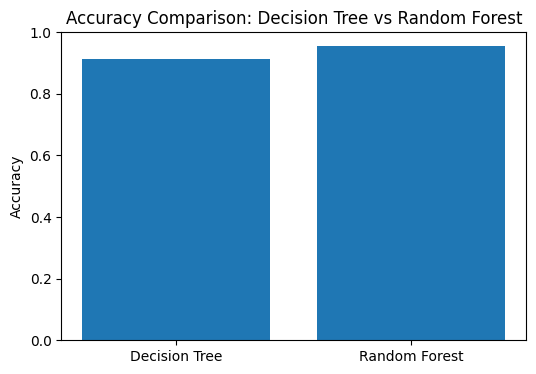

In [10]:

# Vẽ biểu đồ so sánh accuracy

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.bar(comparison["Model"], comparison["Accuracy"])
plt.ylim(0, 1)
plt.title("Accuracy Comparison: Decision Tree vs Random Forest")
plt.ylabel("Accuracy")
plt.show()



# 17. Classification Report

Accuracy chỉ là một chỉ số.

Ta nên xem thêm:

- precision
- recall
- f1-score

Đặc biệt trong bài toán y tế, recall rất quan trọng vì ta không muốn bỏ sót ca bệnh.


In [11]:

print("Decision Tree Classification Report")
print(classification_report(y_test, dt_pred, target_names=data.target_names))


Decision Tree Classification Report
              precision    recall  f1-score   support

   malignant       0.85      0.93      0.89        42
      benign       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



In [12]:

print("Random Forest Classification Report")
print(classification_report(y_test, rf_pred, target_names=data.target_names))


Random Forest Classification Report
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114




# 18. Confusion Matrix


In [13]:

print("Decision Tree Confusion Matrix")
print(confusion_matrix(y_test, dt_pred))


Decision Tree Confusion Matrix
[[39  3]
 [ 7 65]]


In [14]:

print("Random Forest Confusion Matrix")
print(confusion_matrix(y_test, rf_pred))


Random Forest Confusion Matrix
[[39  3]
 [ 2 70]]



# 19. Feature Importance trong Random Forest

Random Forest có thể cho ta biết feature nào quan trọng hơn khi dự đoán.

Đây không phải giải thích hoàn hảo, nhưng rất hữu ích để hiểu model đang dựa nhiều vào biến nào.


In [15]:

feature_importance = pd.DataFrame({
    "Feature": data.feature_names,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance", 
    ascending=False
)

feature_importance.head(10)


,Feature,Importance
23,worst area,0.140016
27,worst concave points,0.129530
20,worst radius,0.097696
7,mean concave points,0.090885
22,worst perimeter,0.072226
2,mean perimeter,0.069574
0,mean radius,0.068676
6,mean concavity,0.057638
3,mean area,0.049172
26,worst concavity,0.034340


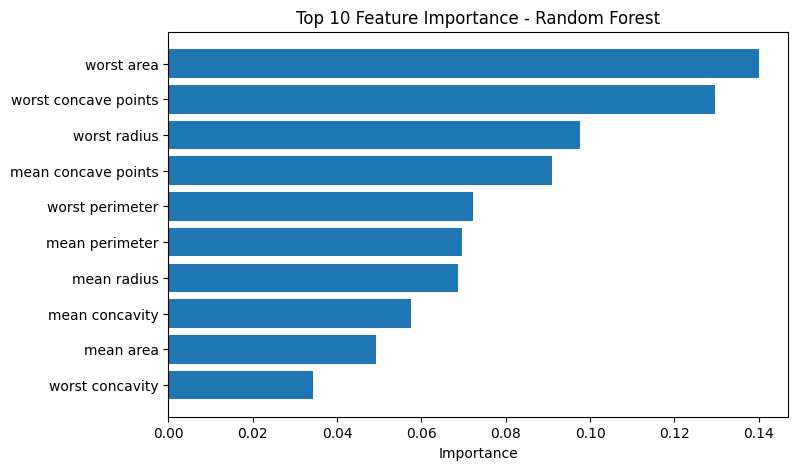

In [16]:

# Vẽ top 10 feature importance

top_10 = feature_importance.head(10)

plt.figure(figsize=(8, 5))
plt.barh(top_10["Feature"], top_10["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.show()



# 20. Thử thay đổi số lượng cây

Ta thử Random Forest với nhiều giá trị `n_estimators` khác nhau.

Mục tiêu:

- xem accuracy thay đổi như thế nào
- hiểu tác động của số lượng cây


In [17]:

n_estimators_list = [1, 5, 10, 50, 100, 200, 500]

results = []

for n in n_estimators_list:
    model = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )

    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)

    results.append({
        "n_estimators": n,
        "accuracy": acc
    })

results_df = pd.DataFrame(results)
results_df


,n_estimators,accuracy
0,1,0.947368
1,5,0.938596
2,10,0.938596
3,50,0.956140
4,100,0.956140
5,200,0.956140
6,500,0.956140


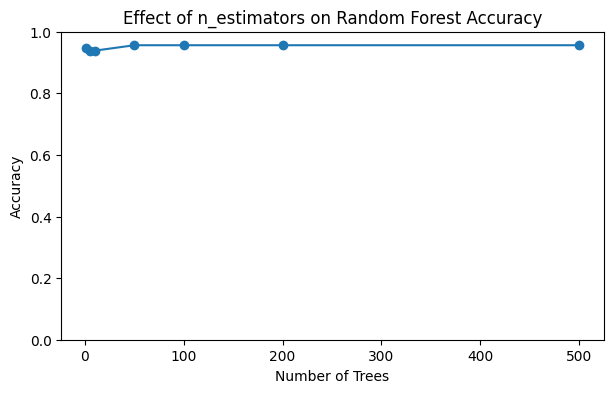

In [18]:

plt.figure(figsize=(7, 4))
plt.plot(results_df["n_estimators"], results_df["accuracy"], marker="o")
plt.title("Effect of n_estimators on Random Forest Accuracy")
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()



# 21. Ý nghĩa kết quả

Thông thường:

- Khi số cây quá ít, model chưa ổn định.
- Khi tăng số cây, accuracy có thể tăng.
- Nhưng sau một mức nào đó, accuracy gần như không tăng thêm nhiều.
- Số cây càng nhiều thì training càng chậm.

Vì vậy, ta không nên tăng số cây vô hạn.

Trong thực tế, các giá trị phổ biến:

```python
n_estimators=100
n_estimators=200
n_estimators=500
```



# 22. Accuracy có phải lúc nào cũng đủ không?

Không.

Ví dụ dataset mất cân bằng:

- 95% không bệnh
- 5% có bệnh

Nếu model luôn dự đoán "không bệnh", accuracy vẫn là 95%.

Nhưng model đó vô dụng vì bỏ sót toàn bộ người có bệnh.

Vì vậy, ngoài accuracy cần xem thêm:

| Metric | Ý nghĩa |
|---|---|
| Precision | Trong các trường hợp model dự đoán positive, bao nhiêu là đúng |
| Recall | Trong các positive thật, model bắt được bao nhiêu |
| F1-score | Trung bình hài hòa giữa precision và recall |
| Confusion Matrix | Bảng thể hiện đúng/sai theo từng class |



# 23. Tổng kết kiến thức

## Bootstrap

Bootstrap là lấy mẫu có hoàn lại.

Mục đích:

- tạo nhiều dataset khác nhau từ dataset gốc,
- giúp các cây học từ những phiên bản data khác nhau.

## Bagging

Bagging là Bootstrap Aggregating.

Mục đích:

- train nhiều model,
- gom kết quả lại,
- giảm variance,
- làm model ổn định hơn.

## Random Forest

Random Forest là nhiều Decision Tree kết hợp với nhau.

Nó dùng:

- bootstrap samples,
- random feature selection,
- majority vote hoặc average.

## Decision Tree vs Random Forest

Decision Tree:

- dễ hiểu,
- nhanh,
- dễ overfit.

Random Forest:

- mạnh hơn,
- ổn định hơn,
- thường accuracy cao hơn,
- khó giải thích hơn.



# 24. Bài tập tự luyện

## Bài 1

Thay đổi `max_depth` của Decision Tree:

```python
DecisionTreeClassifier(max_depth=3)
DecisionTreeClassifier(max_depth=5)
DecisionTreeClassifier(max_depth=10)
```

So sánh accuracy.

---

## Bài 2

Thay đổi `n_estimators` của Random Forest:

```python
n_estimators=10
n_estimators=50
n_estimators=100
n_estimators=300
```

Quan sát accuracy thay đổi như thế nào.

---

## Bài 3

Thử thêm:

```python
max_depth=5
```

vào Random Forest.

So sánh với Random Forest không giới hạn độ sâu.

---

## Bài 4

Dùng `classification_report` để trả lời:

- Model nào có recall tốt hơn?
- Model nào có f1-score tốt hơn?
- Trong bài toán y tế, vì sao recall quan trọng?



# 25. Kết luận cuối

Random Forest là bước nâng cấp tự nhiên sau Decision Tree.

Nếu Decision Tree là một cây đơn lẻ dễ bị overfitting, thì Random Forest là một tập hợp nhiều cây giúp dự đoán ổn định hơn.

Câu cần nhớ:

> Random Forest = nhiều Decision Tree + Bootstrap + Random Feature Selection + Voting

Trong thực tế, Random Forest là một trong những mô hình Machine Learning mạnh, dễ dùng và rất phù hợp cho tabular data.
